#Description 描述
---
資料集來源(https://www.kaggle.com/datasets/kelvinobiri/credit-card-transactions)
---
#雖然資料集叫credit card但整體比較像金融活動的資料集

| 英文            | 解釋                                           |                     |
|-----------------|------------------------------------------------|---------------------|
| step            | Time step of the transaction                   | 交易的時間跨度      |
| type            | Type of transaction (e.g., TRANSFER, CASH_OUT) | 交易類型（例如TRANSFER，CASH_OUT）。 |
| amount          | Amount involved in the transaction             | 交易涉及的金額      |
| nameOrig        | ID of sender account                           | 發件人帳戶的ID      |
| oldbalanceOrg   | Sender’s balance before the transaction        | 交易前發件人的餘額  |
| newbalanceOrig  | Sender’s balance after the transaction         | 交易後發件人的餘額  |
| nameDest        | ID of receiver account                         | 接收器帳戶的ID      |
| oldbalanceDest  | Receiver’s balance before the transaction      | 交易前接收者的餘額  |
| newbalanceDest  | Receiver’s balance after the transaction       | 交易後接收者的餘額  |
| isFraud         | Target variable: 1 if fraudulent, 0 otherwise  | 目標變量：1是欺詐，0否 |
| isPayment       | Indicates if the transaction is a payment      | 指示交易是否是付款  |
| isMovement      | Indicates if it involved a balance change      | 指示是否涉及餘額變化 |
| accountDiff     | Difference in account balances (derived feature) | 帳戶餘額的差異（派生功能） |



In [7]:
import pandas as pd

# 讀取資料
df = pd.read_csv("transactions.csv")  

# 顯示前5筆資料
print(df.head())

# 顯示欄位資訊與缺失值檢查
print(df.info())
print(df.isnull().sum())

# 統計詐騙比例
fraud_rate = df['isFraud'].mean()
print(f"詐騙比例：{fraud_rate:.4f}")


   step      type     amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     8  CASH_OUT  158007.12   C424875646           0.00            0.00   
1   236  CASH_OUT  457948.30  C1342616552           0.00            0.00   
2    37   CASH_IN  153602.99   C900876541    11160428.67     11314031.67   
3   331  CASH_OUT   49555.14   C177696810       10865.00            0.00   
4   250  CASH_OUT   29648.02   C788941490           0.00            0.00   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  
0  C1298177219       474016.32      1618631.97        0  
1  C1323169990      2720411.37      3178359.67        0  
2   C608741097      3274930.56      3121327.56        0  
3   C462716348            0.00        49555.14        0  
4  C1971700992        56933.09        86581.10        0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 199999 entries, 0 to 199998
Data columns (total 10 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   

從上面的欄位描述可以看到nameOrig 跟nameDest 是名稱對於資料分析沒有幫助所以刪掉。

In [8]:
# 移除帳號 ID 欄位
df = df.drop(['nameOrig', 'nameDest'], axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 199999 entries, 0 to 199998
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   step            199999 non-null  int64  
 1   type            199999 non-null  object 
 2   amount          199999 non-null  float64
 3   oldbalanceOrg   199999 non-null  float64
 4   newbalanceOrig  199999 non-null  float64
 5   oldbalanceDest  199999 non-null  float64
 6   newbalanceDest  199999 non-null  float64
 7   isFraud         199999 non-null  int64  
dtypes: float64(5), int64(2), object(1)
memory usage: 12.2+ MB


--------------------資料視覺化---------------------------

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

首先我想看正常交易和詐騙資料的筆數差異

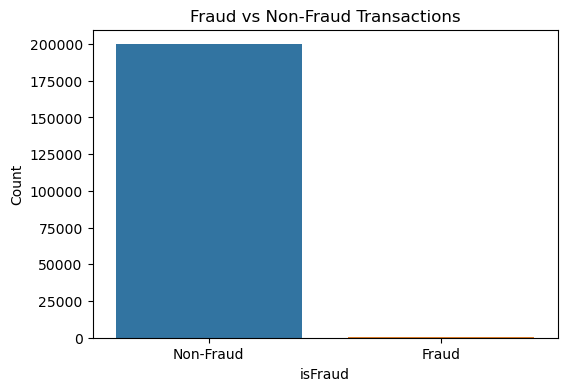

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='isFraud', data=df)
plt.title('Fraud vs Non-Fraud Transactions')
plt.xticks([0,1], ['Non-Fraud', 'Fraud'])
plt.ylabel('Count')
plt.show()

--------------------------------------------------------------------

特徵之間的熱力圖

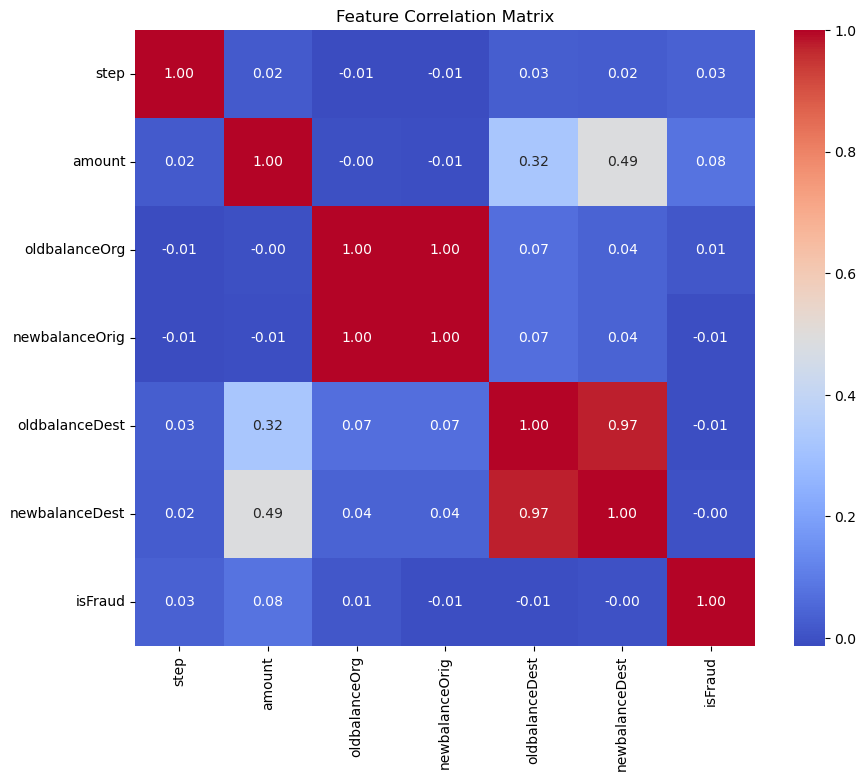

In [ ]:
plt.figure(figsize=(10,8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.show()

--------------------------------------------------------------------

不同類型的筆數分布

CASH_OUT    兌現   
CASH_IN     存錢  
PAYMENT     付款   
TRANSFER    轉帳 
DEBIT       扣款  #自動扣款之類的


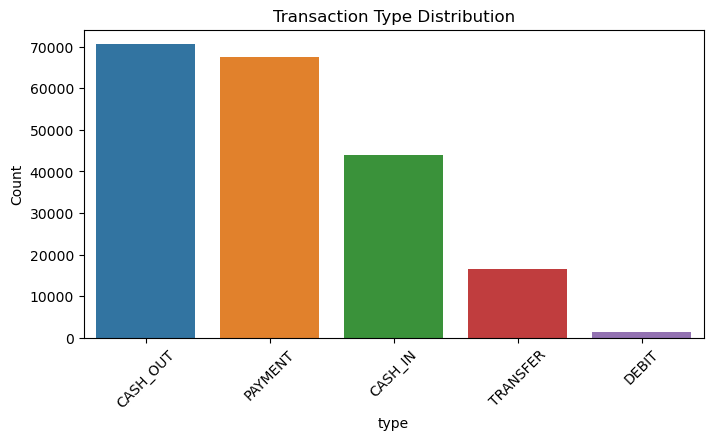

In [10]:
plt.figure(figsize=(8,4))
sns.countplot(x='type', data=df, order=df['type'].value_counts().index)
plt.title('Transaction Type Distribution')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

看完之後我好奇兌現和存錢的金額是多少

--------------------------------------------------------------------

各類交易類型的總金額

type
TRANSFER     15.3B
CASH_OUT     12.4B
CASH_IN       7.4B
PAYMENT     884.4M
DEBIT         6.8M
Name: amount, dtype: object


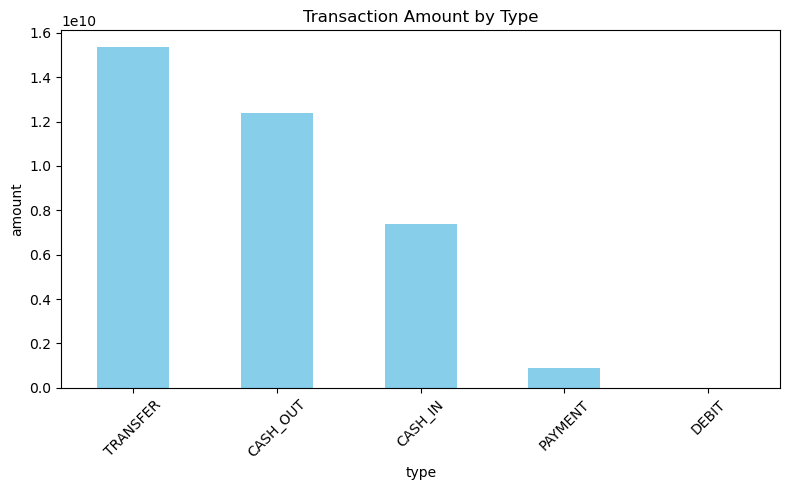

In [ ]:
transaction_amount_by_type = df.groupby('type')['amount'].sum().sort_values(ascending=False)

#單位縮寫
def human_format(num):
    for unit in ['','K','M','B','T']:
        if abs(num) < 1000:
            return f"{num:.1f}{unit}"
        num /= 1000
    return f"{num:.1f}P"  

formatted = transaction_amount_by_type.apply(human_format)
print(formatted)



transaction_amount_by_type.plot(kind='bar', figsize=(8,5), color='skyblue')
plt.title('Transaction Amount by Type')
plt.ylabel('amount')
plt.xlabel('type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


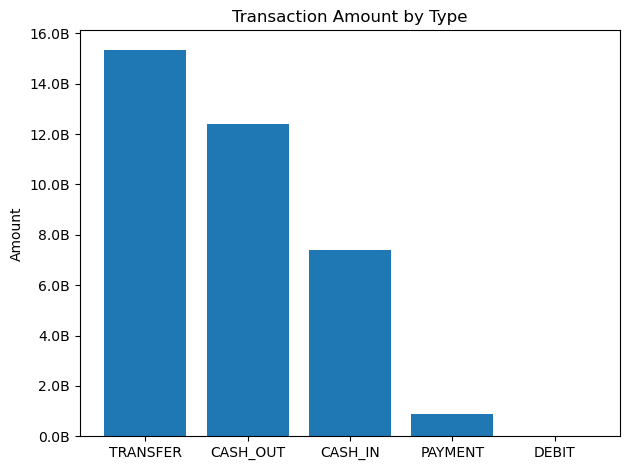

In [22]:
from matplotlib.ticker import FuncFormatter
transaction_amount_by_type = {
    'TRANSFER': 1.534982e+10,
    'CASH_OUT': 1.240312e+10,
    'CASH_IN': 7.404175e+09,
    'PAYMENT': 8.843545e+08,
    'DEBIT': 6.845334e+06
}

fig, ax = plt.subplots()
ax.bar(transaction_amount_by_type.keys(), transaction_amount_by_type.values())

# 設定 Y 軸格式：轉為 Billion 並加 B
def billions(x, pos):
    return f'{x * 1e-9:.1f}B'

ax.yaxis.set_major_formatter(FuncFormatter(billions))

plt.ylabel('Amount')
plt.title('Transaction Amount by Type')
plt.tight_layout()
plt.show()

假如這是一個銀行的數據的話我會建議這家銀行要確保有足夠的現金儲備，並且關注擠兌的情況，Transfer是轉帳代表是同銀行的帳戶間的轉帳，不然的話應該會歸類到Cash_in或Cash_out

--------------------------------------------------------------------

詐騙 vs 非詐騙金額比較(單筆金額)

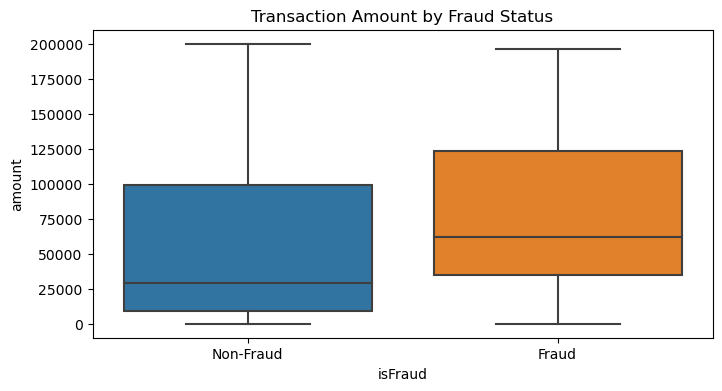

In [15]:
plt.figure(figsize=(8,4))
sns.boxplot(x='isFraud', y='amount', data=df[df['amount'] < 200000])  # 避免極端值干擾
plt.title('Transaction Amount by Fraud Status')
plt.xticks([0,1], ['Non-Fraud', 'Fraud'])
plt.show()

由此可知詐騙交易的金額通常比非詐騙交易來得高

--------------------------------------------------------------------

詐騙 vs 非詐騙的時間跨度比較

Fraud Steps Statistics:
 count    282.000000
mean     374.503546
std      200.635472
min        2.000000
25%      210.500000
50%      370.000000
75%      535.250000
max      741.000000
Name: step, dtype: float64

Non-Fraud Steps Statistics:
 count    199717.000000
mean        243.104563
std         141.614910
min           1.000000
25%         156.000000
50%         238.000000
75%         334.000000
max         718.000000
Name: step, dtype: float64


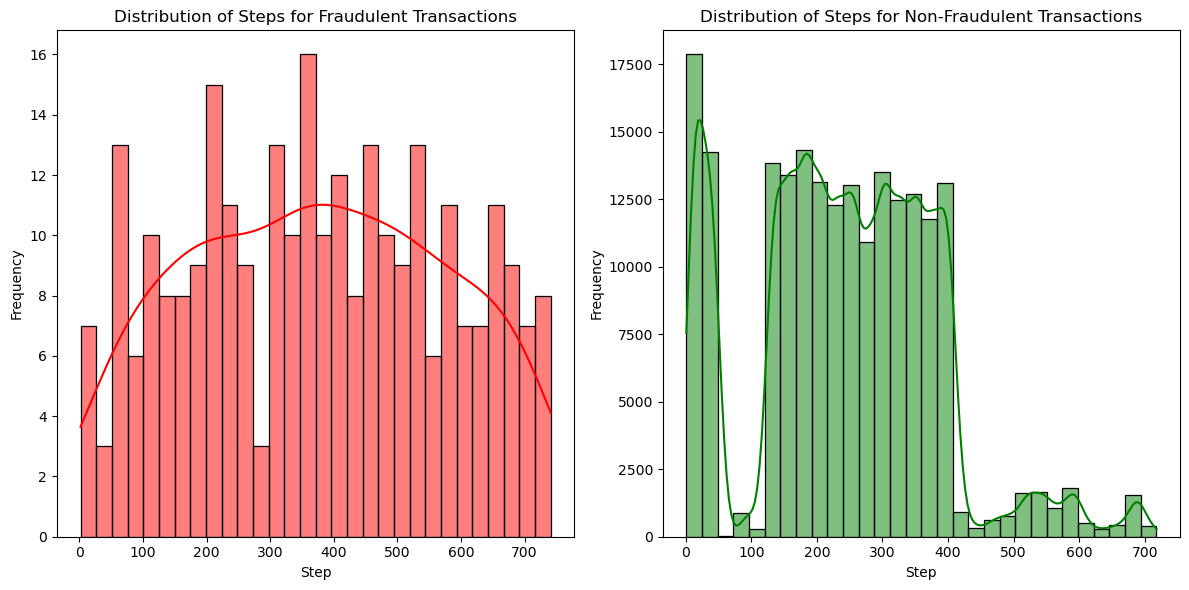

In [24]:


# 假設 df 是你的資料集
# 篩選出 isFraud=1 和 isFraud=0 的資料
fraud_steps = df[df['isFraud'] == 1]['step']
non_fraud_steps = df[df['isFraud'] == 0]['step']

# 統計描述
fraud_stats = fraud_steps.describe()
non_fraud_stats = non_fraud_steps.describe()

print("Fraud Steps Statistics:\n", fraud_stats)
print("\nNon-Fraud Steps Statistics:\n", non_fraud_stats)

# 可視化
plt.figure(figsize=(12, 6))

# 直方圖
plt.subplot(1, 2, 1)
sns.histplot(fraud_steps, bins=30, color='red', kde=True)
plt.title('Distribution of Steps for Fraudulent Transactions')
plt.xlabel('Step')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.histplot(non_fraud_steps, bins=30, color='green', kde=True)
plt.title('Distribution of Steps for Non-Fraudulent Transactions')
plt.xlabel('Step')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


從圖中我們可以看到詐騙和非詐騙的時間跨度型態差異非常大，建議超過400可以考慮列入警示用戶，以及為何詐騙集團在275至300這個區間會突然下降這麼多

--------------------------------------------------------------------